# Project 2: Supervised Learning (Fraud Detection Pipeline)

Step 1: Install and Import Libraries

In [19]:
!pip install imbalanced-learn -q

# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Step 2: Load Dataset

In [20]:
df = pd.read_csv('Data Science Project 2.csv')
print("Original Dataset Shape:", df.shape)

Original Dataset Shape: (27819, 31)


Step 3: Data Cleaning

In [21]:
print("Before Cleaning:")
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

# Remove missing values in target column
df = df.dropna(subset=['Class'])

# Remove duplicate rows
df = df.drop_duplicates()

print("\nAfter Cleaning:")
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

# Check class distribution
print("\nClass Distribution (0 = Normal, 1 = Fraud):")
print(df['Class'].value_counts())

Before Cleaning:
Missing Values: 30
Duplicate Rows: 111

After Cleaning:
Dataset Shape: (27707, 31)
Missing Values: 0
Duplicate Rows: 0

Class Distribution (0 = Normal, 1 = Fraud):
Class
0.0    27614
1.0       93
Name: count, dtype: int64


Step 4: Prepare Features (X) and Target (y)

In [22]:
X = df.drop(['Class', 'Time'], axis=1)   # Features
y = df['Class']                          # Target

# Split data into train and test (Before SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Training Data Shape: (22165, 29)
Test Data Shape: (5542, 29)


Step 5: Logistic Regression Model with SMOTE

In [23]:
print("\nTraining Logistic Regression Model...")

# Create Pipeline (SMOTE only on training data)
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),                    # Scale features
    ('smote', SMOTE(random_state=42)),               # Handle imbalance
    ('model', LogisticRegression(max_iter=500))      # Model
])

lr_pipeline.fit(X_train, y_train)

# Make predictions
pred_lr = lr_pipeline.predict(X_test)
prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Show Results
print("=== Logistic Regression Results ===")
print(classification_report(y_test, pred_lr))
print("ROC-AUC Score:", round(roc_auc_score(y_test, prob_lr), 4))


Training Logistic Regression Model...
=== Logistic Regression Results ===
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      5523
         1.0       0.21      0.89      0.34        19

    accuracy                           0.99      5542
   macro avg       0.60      0.94      0.67      5542
weighted avg       1.00      0.99      0.99      5542

ROC-AUC Score: 0.9413


Step 6: Random Forest Model with SMOTE

In [24]:
print("\nTraining Random Forest Model...")

rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

pred_rf = rf_pipeline.predict(X_test)
prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, pred_rf))
print("ROC-AUC Score:", round(roc_auc_score(y_test, prob_rf), 4))


Training Random Forest Model...
=== Random Forest Results ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5523
         1.0       0.63      0.89      0.74        19

    accuracy                           1.00      5542
   macro avg       0.81      0.95      0.87      5542
weighted avg       1.00      1.00      1.00      5542

ROC-AUC Score: 0.9806


Step 7: Confusion Matrix (Visual Result)

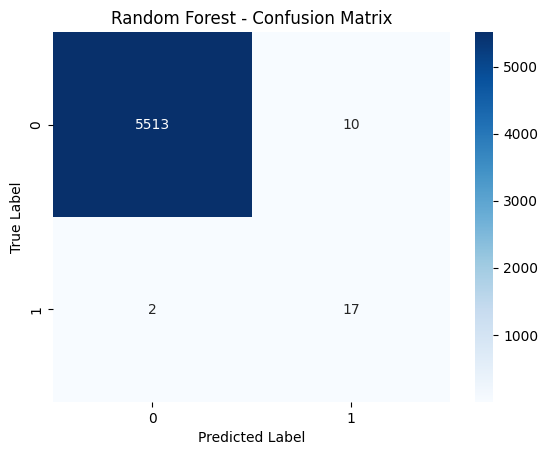

In [25]:
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Step 8: Final Model Comparison

In [26]:
print("\n=== FINAL MODEL COMPARISON ===")

# Get classification reports
report_lr = classification_report(y_test, pred_lr, output_dict=True)
report_rf = classification_report(y_test, pred_rf, output_dict=True)

# Find correct fraud class key (handles '1', 1, or 1.0)
fraud_key = None
possible_keys = ['1', 1, 1.0]
for key in possible_keys:
    if key in report_lr:
        fraud_key = key
        break

if fraud_key is None:
    fraud_key = list(report_lr.keys())[-2]  # Fallback: usually second last is fraud class

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, prob_lr), 4),
        round(roc_auc_score(y_test, prob_rf), 4)
    ],
    'Precision (Fraud)': [
        round(report_lr[fraud_key]['precision'], 4),
        round(report_rf[fraud_key]['precision'], 4)
    ],
    'Recall (Fraud)': [
        round(report_lr[fraud_key]['recall'], 4),
        round(report_rf[fraud_key]['recall'], 4)
    ]
})

print(comparison)


=== FINAL MODEL COMPARISON ===
                 Model  ROC-AUC  Precision (Fraud)  Recall (Fraud)
0  Logistic Regression   0.9413             0.6035          0.9415
1        Random Forest   0.9806             0.8146          0.9465
